# 04 – Bidding Evaluation: Newsvendor-Based Wind Power Trading

Dieses Notebook bewertet alle Forecasting-Modelle aus Notebook 03 **ökonomisch**.

## Entscheidungslogik

### Schicht 1 – Gewinnfunktion
$$\pi_t = p_{DA,t} \cdot b_t + p_{reBAP,t} \cdot (y_t - b_t)$$

### Schicht 2 – Newsvendor-Verlustfunktion
$$L_t = c_{under} \cdot \max(b_t - y_t, 0) + c_{over} \cdot \max(y_t - b_t, 0)$$

mit:
- $c_{under} = \mathbb{E}[\max(p_{reBAP} - p_{DA}, 0)]$ → Unterdeckung teuer wenn reBAP > DA
- $c_{over}  = \mathbb{E}[\max(p_{DA} - p_{reBAP}, 0)]$ → Überdeckung teuer wenn DA > reBAP

### Schicht 3 – Optimales Quantil (klassischer Newsvendor)
$$\tau^* = \frac{c_{under}}{c_{under} + c_{over}}$$

### Schicht 4 – Distributionally Robust Bernoulli Newsvendor (Pinson 2022/2023)

Im Bernoulli-Newsvendor wird der Erzeuger entweder für Über- **oder** Unterdeckung bestraft (nie beides). Die Richtungsvariable $s_t = \mathbf{1}\{p_{reBAP,t} > p_{DA,t}\}$ ist Bernoulli-verteilt mit $\tau = \mathbb{P}(s_t = 1)$.

Die robuste Erweiterung schützt gegen **Ambiguität** in den Modellparametern:
- **Theorem 1** (Pinson 2022): Ambiguität über $\hat{F}_\omega$ → Wasserstein-verzerrte Quantilfunktion
- **Theorem 2** (Pinson 2022): Ambiguität über $\hat{\tau}$ → Konfidenzintervall $[\tau_L, \tau_U]$, robuste Wahl $\tau_{rob} = \tau_U$

## Datengrundlage

- **reBAP**: Regelenergie-Ausgleichspreise (15-min, aggregiert auf Stunden)
- **p_DA**: Stündliche EPEX Day-Ahead-Preise (SMARD/Bundesnetzagentur)
- **c_under / c_over**: Geschätzt aus dem Trainingszeitraum (kein Data Leakage)

## Zentrale Forschungsfrage

```
Forecast → Bid (Newsvendor / DR-BNP) → Profit / Newsvendor Loss
```

Ist das Modell mit bestem RMSE auch wirtschaftlich am besten?  
Bringt die DR-Robustifizierung einen Mehrwert gegenüber dem klassischen Newsvendor?

## 1. Setup und Imports

In [139]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Pfade
REBAP_DIR    = PROJECT_ROOT / "data" / "raw" / "Daten zu reBAP Preisen"
MARKT_DIR    = PROJECT_ROOT / "data" / "raw" / "Daten zu Marktpreisen"
FORECAST_DIR = PROJECT_ROOT / "results" / "forecasts"
RESULTS_DIR  = PROJECT_ROOT / "results"
TABLES_DIR   = RESULTS_DIR / "tables"
FIGURES_DIR  = RESULTS_DIR / "figures"

for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\felix\Documents\AI1\wind_bidding_project


In [140]:
from src.bidding.newsvendor import compute_costs, optimal_quantile, loss, profit

## 2. reBAP-Daten laden und auf Stunden aggregieren

Die reBAP-Daten liegen im 15-Minuten-Raster vor (deutsches Format: Semikolon, Komma als Dezimaltrennzeichen).  
Hinweis: **2021 fehlt** in den vorhandenen Dateien.

Für das Bidding-Modell verwenden wir den Mittelwert aus `reBAP unterdeckt` und `reBAP ueberdeckt` pro Stunde.

In [141]:
def load_rebap_file(path: Path) -> pd.DataFrame:
    """Lädt eine reBAP-CSV (15-min, deutsches Format) und gibt einen sauberen DataFrame zurück."""
    df = pd.read_csv(
        path,
        sep=";",
        decimal=",",
        encoding="utf-8-sig",   # BOM entfernen
        usecols=["Datum", "von", "reBAP unterdeckt", "reBAP ueberdeckt"],
    )

    df["timestamp"] = pd.to_datetime(
        df["Datum"] + " " + df["von"],
        format="%d.%m.%Y %H:%M",
        errors="coerce",
    )

    df = df.dropna(subset=["timestamp"]).copy()
    df = df.rename(columns={
        "reBAP unterdeckt": "rebap_under",
        "reBAP ueberdeckt": "rebap_over",
    })

    # Mittlerer reBAP pro 15-min-Slot
    df["rebap"] = (df["rebap_under"] + df["rebap_over"]) / 2

    return df[["timestamp", "rebap", "rebap_under", "rebap_over"]]


# Alle Jahre einlesen
rebap_files = sorted(REBAP_DIR.glob("reBAP *.csv"))
print(f"Gefundene reBAP-Dateien: {len(rebap_files)}")
for f in rebap_files:
    print(" ", f.name)

rebap_raw = pd.concat(
    [load_rebap_file(f) for f in rebap_files],
    ignore_index=True,
).sort_values("timestamp").reset_index(drop=True)

print("\nreBAP 15-min Shape:", rebap_raw.shape)
print("Zeitraum:", rebap_raw["timestamp"].min(), "bis", rebap_raw["timestamp"].max())
rebap_raw.head()

Gefundene reBAP-Dateien: 10
  reBAP 2016.csv
  reBAP 2017.csv
  reBAP 2018.csv
  reBAP 2019.csv
  reBAP 2020.csv
  reBAP 2021.csv
  reBAP 2022.csv
  reBAP 2023.csv
  reBAP 2024.csv
  reBAP 2025.csv

reBAP 15-min Shape: (350688, 4)
Zeitraum: 2016-01-01 00:00:00 bis 2025-12-31 23:45:00


,timestamp,rebap,rebap_under,rebap_over
0,2016-01-01 00:00:00,-47.43,-47.43,-47.43
1,2016-01-01 00:15:00,78.73,78.73,78.73
2,2016-01-01 00:30:00,45.75,45.75,45.75
3,2016-01-01 00:45:00,37.41,37.41,37.41
4,2016-01-01 01:00:00,65.72,65.72,65.72


In [142]:
# Auf Stunden aggregieren (Mittelwert der 4 Slots pro Stunde)
rebap_hourly = (
    rebap_raw
    .set_index("timestamp")
    .resample("h")[["rebap", "rebap_under", "rebap_over"]]
    .mean()
    .reset_index()
)

print("reBAP stündlich Shape:", rebap_hourly.shape)
rebap_hourly.head()

reBAP stündlich Shape: (87672, 4)


,timestamp,rebap,rebap_under,rebap_over
0,2016-01-01 00:00:00,28.6150,28.6150,28.6150
1,2016-01-01 01:00:00,-0.8025,-0.8025,-0.8025
2,2016-01-01 02:00:00,53.8300,53.8300,53.8300
3,2016-01-01 03:00:00,45.1050,45.1050,45.1050
4,2016-01-01 04:00:00,20.6700,20.6700,20.6700


## 2b. EPEX Day-Ahead-Preise laden

Day-Ahead-Preise vom SMARD-Portal (Bundesnetzagentur):
- **2016–Sep 2018**: Marktgebiet DE/AT/LU (Österreich noch in gemeinsamer Zone)
- **Okt 2018–2025**: Marktgebiet DE/LU

Beide Dateien werden zusammengefügt und ersetzen die bisherige Approximation $p_{DA} \approx \bar{p}_{reBAP}$.

In [143]:
def load_smard(path: Path, price_col: str) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        sep=";",
        decimal=",",
        encoding="utf-8-sig",
        usecols=["Datum von", price_col],
    )
    df["timestamp"] = pd.to_datetime(df["Datum von"], format="%d.%m.%Y %H:%M")
    df["da_price"]  = pd.to_numeric(df[price_col], errors="coerce")
    return df[["timestamp", "da_price"]].dropna(subset=["da_price"])


da_pre  = load_smard(
    MARKT_DIR / "Gro_handelspreise_201601010000_201810010000_Stunde.csv",
    "DE/AT/LU [€/MWh] Berechnete Auflösungen",
)
da_post = load_smard(
    MARKT_DIR / "Gro_handelspreise_201610010000_202601010000_Stunde.csv",
    "Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen",
)

da_prices = (
    pd.concat([da_pre, da_post])
    .sort_values("timestamp")
    .drop_duplicates("timestamp")
    .reset_index(drop=True)
)

print("DA-Preise Shape:", da_prices.shape)
print("Zeitraum:", da_prices["timestamp"].min(), "bis", da_prices["timestamp"].max())
print(f"Mittlerer DA-Preis: {da_prices['da_price'].mean():.2f} EUR/MWh")
da_prices.head()

DA-Preise Shape: (72416, 2)
Zeitraum: 2016-01-01 00:00:00 bis 2025-12-31 23:00:00
Mittlerer DA-Preis: 85.77 EUR/MWh


C:\Users\felix\AppData\Local\Temp\ipykernel_14176\3163047669.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,timestamp,da_price
0,2016-01-01 00:00:00,23.86
1,2016-01-01 01:00:00,22.39
2,2016-01-01 02:00:00,20.59
3,2016-01-01 03:00:00,16.81
4,2016-01-01 04:00:00,17.41


## 3. Forecast-Predictions laden

In [144]:
predictions = pd.read_csv(
    FORECAST_DIR / "predictions_day_ahead.csv",
    parse_dates=["timestamp"],
)

print("Predictions Shape:", predictions.shape)
print("Testzeitraum:", predictions["timestamp"].min(), "bis", predictions["timestamp"].max())
predictions.head()

Predictions Shape: (13816, 26)
Testzeitraum: 2023-12-07 03:00:00 bis 2025-08-31 23:00:00


,timestamp,y_true,persistence_gate,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90
0,2023-12-07 03:00:00,0.683483,1.440683,1.735109,1.712108,1.694821,0.078341,0.407412,1.294931,2.480991,...,0.090291,0.343357,1.173904,2.377029,4.299697,0.156311,0.591537,1.689958,3.327141,5.003766
1,2023-12-07 04:00:00,1.120767,1.440683,1.710009,1.790606,1.694821,0.079038,0.400532,1.246877,2.384050,...,0.092044,0.343357,1.165868,2.377029,4.299697,0.166100,0.612103,1.699433,3.307512,4.957318
2,2023-12-07 05:00:00,1.251583,1.440683,1.680779,1.825095,1.694821,0.079564,0.391714,1.191615,2.283215,...,0.096253,0.343357,1.165868,2.377029,4.299697,0.173217,0.626701,1.704932,3.294596,4.928760
3,2023-12-07 06:00:00,0.879967,1.440683,1.649411,1.894520,1.694821,0.079881,0.381560,1.132910,2.185356,...,0.096253,0.343357,1.165868,2.377029,4.299697,0.174265,0.625279,1.690415,3.271869,4.907371
4,2023-12-07 07:00:00,0.521533,1.440683,1.618043,1.960409,1.694821,0.079968,0.370762,1.074762,2.097144,...,0.096253,0.343357,1.082071,2.364868,4.299697,0.170216,0.610903,1.661577,3.245276,4.897727


In [145]:
df = (
    predictions
    .merge(rebap_hourly, on="timestamp", how="inner")
    .merge(da_prices,    on="timestamp", how="inner")
)

print("Merged Shape:", df.shape)
missing = len(predictions) - len(df)
if missing > 0:
    warnings.warn(f"{missing} Stunden ohne reBAP- oder DA-Daten wurden entfernt.")

df.head()

Merged Shape: (13814, 30)


C:\Users\felix\AppData\Local\Temp\ipykernel_14176\2369287899.py:10: UserWarning: 2 Stunden ohne reBAP- oder DA-Daten wurden entfernt.
  warnings.warn(f"{missing} Stunden ohne reBAP- oder DA-Daten wurden entfernt.")


,timestamp,y_true,persistence_gate,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90,rebap,rebap_under,rebap_over,da_price
0,2023-12-07 03:00:00,0.683483,1.440683,1.735109,1.712108,1.694821,0.078341,0.407412,1.294931,2.480991,...,4.299697,0.156311,0.591537,1.689958,3.327141,5.003766,139.3400,139.3400,139.3400,91.81
1,2023-12-07 04:00:00,1.120767,1.440683,1.710009,1.790606,1.694821,0.079038,0.400532,1.246877,2.384050,...,4.299697,0.166100,0.612103,1.699433,3.307512,4.957318,146.8000,146.8000,146.8000,89.92
2,2023-12-07 05:00:00,1.251583,1.440683,1.680779,1.825095,1.694821,0.079564,0.391714,1.191615,2.283215,...,4.299697,0.173217,0.626701,1.704932,3.294596,4.928760,147.8975,147.8975,147.8975,94.53
3,2023-12-07 06:00:00,0.879967,1.440683,1.649411,1.894520,1.694821,0.079881,0.381560,1.132910,2.185356,...,4.299697,0.174265,0.625279,1.690415,3.271869,4.907371,193.7850,193.7850,193.7850,116.58
4,2023-12-07 07:00:00,0.521533,1.440683,1.618043,1.960409,1.694821,0.079968,0.370762,1.074762,2.097144,...,4.299697,0.170216,0.610903,1.661577,3.245276,4.897727,216.9925,216.9925,216.9925,131.22


## 5. Newsvendor-Kostenstruktur berechnen

> **Hinweis:** Dieser Abschnitt (statisches τ*) wird ggf. noch entfernt.

$$c_{under} = \mathbb{E}[\max(p_{reBAP} - p_{DA}, 0)], \quad c_{over} = \mathbb{E}[\max(p_{DA} - p_{reBAP}, 0)]$$

$p_{DA}$ sind stündliche EPEX Day-Ahead-Preise (SMARD/Bundesnetzagentur).  
c_under und c_over werden aus dem **Trainingszeitraum** geschätzt (vor dem Testzeitraum der Predictions).

In [146]:
test_start = df["timestamp"].min()

# c_under/c_over aus Trainingsdaten schätzen (kein Data Leakage)
train_prices = (
    rebap_hourly[rebap_hourly["timestamp"] < test_start]
    .merge(da_prices, on="timestamp", how="inner")
)

p_rebap_train = train_prices["rebap"].to_numpy()
p_da_train    = train_prices["da_price"].to_numpy()

c_under, c_over = compute_costs(p_da_train, p_rebap_train)
tau_star = optimal_quantile(c_under, c_over) if (c_under + c_over) > 0 else 0.5

# Testvektoren für Gewinn- und Verlustberechnung
p_rebap = df["rebap"].to_numpy()
p_da    = df["da_price"].to_numpy()

print(f"Trainingszeitraum für Kosten: bis {test_start.date()}")
print(f"Trainings-Stunden:             {len(train_prices)}")
print(f"c_under:                       {c_under:.4f} EUR/MWh")
print(f"c_over:                        {c_over:.4f} EUR/MWh")
print(f"τ* (statisch):                 {tau_star:.4f}")

Trainingszeitraum für Kosten: bis 2023-12-07
Trainings-Stunden:             54277
c_under:                       28.5658 EUR/MWh
c_over:                        30.6229 EUR/MWh
τ* (statisch):                 0.4826


## 5b. Dynamisches τ* (Pinson-Ansatz)

Statt eines fixen τ* wird für jede Stunde t ein eigenes optimales Quantil berechnet:

$$\tau^*_t = \frac{\hat{c}_{under,t}}{\hat{c}_{under,t} + \hat{c}_{over,t}}$$

$\hat{c}_{under,t}$ und $\hat{c}_{over,t}$ werden aus einem **rollenden Fenster** der letzten 30 Tage geschätzt.  
Dadurch reagiert τ* auf Veränderungen in der Preisstruktur (z.B. Energiekrise 2022).

In [147]:
WINDOW = 30 * 24  # 30 Tage in Stunden

# Alle Preisdaten kombiniert (Training + Test) für Rolling-Berechnung
all_prices = (
    rebap_hourly
    .merge(da_prices, on="timestamp", how="inner")
    [["timestamp", "rebap", "da_price"]]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# shift(1): nur vergangene Daten → kein Leakage
all_prices["c_under_roll"] = (
    np.maximum(all_prices["rebap"] - all_prices["da_price"], 0)
    .shift(1).rolling(WINDOW, min_periods=168).mean()
)
all_prices["c_over_roll"] = (
    np.maximum(all_prices["da_price"] - all_prices["rebap"], 0)
    .shift(1).rolling(WINDOW, min_periods=168).mean()
)
all_prices["tau_star_dyn"] = (
    all_prices["c_under_roll"] /
    (all_prices["c_under_roll"] + all_prices["c_over_roll"])
).clip(0.01, 0.99)

# Auf Testzeitraum einschränken
tau_dyn = (
    df[["timestamp"]]
    .merge(all_prices[["timestamp", "tau_star_dyn"]], on="timestamp", how="left")
    ["tau_star_dyn"]
    .fillna(tau_star)
    .to_numpy()
)

print(f"τ* statisch:              {tau_star:.4f}")
print(f"τ* dynamisch – Mittel:    {tau_dyn.mean():.4f}")
print(f"τ* dynamisch – Std:       {tau_dyn.std():.4f}")
print(f"τ* dynamisch – [Min,Max]: [{tau_dyn.min():.4f}, {tau_dyn.max():.4f}]")

τ* statisch:              0.4826
τ* dynamisch – Mittel:    0.5293
τ* dynamisch – Std:       0.0858
τ* dynamisch – [Min,Max]: [0.2626, 0.7283]


## 6. Hilfsfunktionen für Bidding-Evaluation

In [148]:
def evaluate_bid(
    model_name: str,
    bid: np.ndarray,
    y_true: np.ndarray,
    p_da: np.ndarray,
    p_rebap: np.ndarray,
    c_under: float,
    c_over: float,
) -> dict:
    """Berechnet alle ökonomischen Kennzahlen für ein Gebots-Array."""
    bid = np.clip(bid, 0, None)   # sicherheitshalber clipping

    nv_loss  = loss(bid, y_true, c_under, c_over)
    profits  = profit(bid, y_true, p_da, p_rebap)

    return {
        "model":              model_name,
        "mean_profit":        float(np.mean(profits)),
        "total_profit":       float(np.sum(profits)),
        "mean_nv_loss":       float(np.mean(nv_loss)),
        "total_nv_loss":      float(np.sum(nv_loss)),
        "mean_abs_imbalance": float(np.mean(np.abs(y_true - bid))),
        "underbid_ratio":     float(np.mean(bid < y_true)),   # Anteil Unterdeckung
        "overbid_ratio":      float(np.mean(bid > y_true)),   # Anteil Überdeckung
        "_bid":               bid,
        "_profits":           profits,
        "_nv_loss":           nv_loss,
    }


y_true  = df["y_true"].to_numpy()
results = []   # sammelt alle Ergebnisse

## 7. Point Forecast Bidding

Bei Point Forecasts gilt: $b_t = \hat{y}_t$  
Das Modell bietet direkt seine Punktvorhersage — kein Quantil-Tuning möglich.

In [149]:
point_models = {
    "Persistence_gate":  df["persistence_gate"].to_numpy(),
    "Elastic_Net":       df["elastic_net"].to_numpy(),
    "Random_Forest":     df["random_forest"].to_numpy(),
    "Gradient_Boosting": df["gradient_boosting"].to_numpy(),
}

for name, bid in point_models.items():
    r = evaluate_bid(name, bid, y_true, p_da, p_rebap, c_under, c_over)
    results.append(r)
    print(f"{name:<25} mean_profit={r['mean_profit']:+.4f}  mean_nv_loss={r['mean_nv_loss']:.4f}")

Persistence_gate          mean_profit=+113.2278  mean_nv_loss=39.7571
Elastic_Net               mean_profit=+107.8538  mean_nv_loss=37.3608
Random_Forest             mean_profit=+110.8078  mean_nv_loss=37.7601
Gradient_Boosting         mean_profit=+107.6846  mean_nv_loss=37.6100


## 8. Probabilistic Forecast Bidding

Drei Bidding-Strategien werden parallel verglichen:

| Strategie | Bid | Beschreibung |
|---|---|---|
| **Median** | $Q_{0.5}$ | Naive Baseline, ignoriert Kostenasymmetrie |
| **τ* statisch** | $Q_{\tau^*}$ | Newsvendor-optimal, τ* aus Trainingsdaten |
| **τ* dynamisch** | $Q_{\tau^*_t}$ | Pinson-Ansatz: rollender 30-Tage-Schätzer |

In [150]:
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]

def get_quantile_bid(model_prefix: str, tau: float) -> np.ndarray:
    """Statisches τ: lineares Interpolieren zwischen den nächsten zwei Quantilen."""
    exact_col = f"{model_prefix}_q{int(tau * 100):02d}"
    if exact_col in df.columns:
        return df[exact_col].to_numpy()
    lower = max((q for q in QUANTILES if q <= tau), default=QUANTILES[0])
    upper = min((q for q in QUANTILES if q >= tau), default=QUANTILES[-1])
    col_low  = f"{model_prefix}_q{int(lower * 100):02d}"
    col_high = f"{model_prefix}_q{int(upper * 100):02d}"
    if lower == upper:
        return df[col_low].to_numpy()
    w = (tau - lower) / (upper - lower)
    return (1 - w) * df[col_low].to_numpy() + w * df[col_high].to_numpy()


def get_dynamic_quantile_bid(model_prefix: str, tau_arr: np.ndarray) -> np.ndarray:
    """Dynamisches τ (Pinson): jede Stunde ihr eigenes τ*_t, vektorisiert."""
    q_cols = [f"{model_prefix}_q{int(q*100):02d}" for q in QUANTILES]
    Q = df[q_cols].to_numpy()
    tau_arr = np.clip(tau_arr, QUANTILES[0], QUANTILES[-1])
    bids = np.zeros(len(tau_arr))
    for j in range(len(QUANTILES) - 1):
        lo, hi = QUANTILES[j], QUANTILES[j + 1]
        mask = (tau_arr >= lo) & (tau_arr < hi)
        if mask.any():
            w = (tau_arr[mask] - lo) / (hi - lo)
            bids[mask] = (1 - w) * Q[mask, j] + w * Q[mask, j + 1]
    bids[tau_arr >= QUANTILES[-1]] = Q[tau_arr >= QUANTILES[-1], -1]
    return bids


prob_models = {
    "quantile_regression": "Quantile_Regression",
    "qrf":                  "QRF",
    "qgb":                  "Quantile_Gradient_Boosting",
    "qnn":                  "Quantile_Neural_Network",
}

for col_prefix, display_name in prob_models.items():
    r = evaluate_bid(f"{display_name} (q50)",
                     get_quantile_bid(col_prefix, 0.5),
                     y_true, p_da, p_rebap, c_under, c_over)
    results.append(r)

    r_stat = evaluate_bid(f"{display_name} (τ* statisch={tau_star:.2f})",
                          get_quantile_bid(col_prefix, tau_star),
                          y_true, p_da, p_rebap, c_under, c_over)
    results.append(r_stat)

    r_dyn = evaluate_bid(f"{display_name} (τ* dynamisch)",
                         get_dynamic_quantile_bid(col_prefix, tau_dyn),
                         y_true, p_da, p_rebap, c_under, c_over)
    results.append(r_dyn)

    print(f"{display_name:<35} "
          f"q50={results[-3]['mean_nv_loss']:.2f}  "
          f"τ*_stat={results[-2]['mean_nv_loss']:.2f}  "
          f"τ*_dyn={results[-1]['mean_nv_loss']:.2f}")

Quantile_Regression                 q50=34.93  τ*_stat=34.95  τ*_dyn=35.57
QRF                                 q50=35.92  τ*_stat=35.73  τ*_dyn=36.52
Quantile_Gradient_Boosting          q50=34.82  τ*_stat=34.89  τ*_dyn=35.27
Quantile_Neural_Network             q50=34.50  τ*_stat=34.50  τ*_dyn=35.01


In [151]:
# ============================================================
# DR-BNP Theorem 1 (Pinson 2022/2023)
# Ambiguität über F̂_ω (die Prognoseverteilung der Windleistung)
# ============================================================
# Wasserstein-Kugel der Größe ε um F̂_ω: F* ist die pessimistischste
# Verteilung, die den erwarteten Newsvendor-Verlust maximiert.
#
# Robuste Lösung (Theorem 1):
#   y*_DR = (1 - ε/σ_ω) · Q_τ̂(F̂_ω) + (ε/σ_ω) · Extremquantil
# → der Bid rückt vom nominellen Quantil weg Richtung worst-case Tail.
#   Für τ̂ > 0.5 (Unterdeckung teurer): Richtung oberes Quantil (Q_0.90).
#   Für τ̂ < 0.5 (Überdeckung teurer):  Richtung unteres Quantil (Q_0.10).
#
# σ_ω ≈ IQR / 1.35 (robuste Standardabweichungsschätzung aus Quantilbreite).

def dr_bnp_thm1_bid(
    col_prefix: str,
    tau_hat: float,
    eps: float,
) -> np.ndarray:
    """DR-BNP Theorem 1: Wasserstein-robustes Gebot bei Ambiguität über F̂_ω."""
    iqr = (df[f"{col_prefix}_q75"] - df[f"{col_prefix}_q25"]).to_numpy()
    sigma_omega = np.maximum(iqr / 1.35, 1e-6)

    q_nominal = get_quantile_bid(col_prefix, tau_hat)

    if tau_hat >= 0.5:
        q_extreme = df[f"{col_prefix}_q90"].to_numpy()   # worst-case: mehr Unterdeckung
    else:
        q_extreme = df[f"{col_prefix}_q10"].to_numpy()   # worst-case: mehr Überdeckung

    weight = np.clip(eps / sigma_omega, 0.0, 1.0)
    return (1.0 - weight) * q_nominal + weight * q_extreme


EPS_VALUES = [0.10, 0.20, 0.30]

print("=== DR-BNP Theorem 1: Wasserstein-Ambiguität über F̂_ω ===")
print(f"  Nominelles τ̂ = {tau_star:.4f}")
print()

for eps in EPS_VALUES:
    print(f"  ε = {eps:.2f}:")
    for col_prefix, display_name in prob_models.items():
        bid_dr = dr_bnp_thm1_bid(col_prefix, tau_star, eps)
        r_dr = evaluate_bid(
            f"{display_name} (DR-T1 ε={eps:.2f})",
            bid_dr, y_true, p_da, p_rebap, c_under, c_over,
        )
        results.append(r_dr)
        print(f"    {display_name:<35}  NV-Loss={r_dr['mean_nv_loss']:.2f}")
    print()

=== DR-BNP Theorem 1: Wasserstein-Ambiguität über F̂_ω ===
  Nominelles τ̂ = 0.4826

  ε = 0.10:
    Quantile_Regression                  NV-Loss=35.02
    QRF                                  NV-Loss=35.59
    Quantile_Gradient_Boosting           NV-Loss=35.00
    Quantile_Neural_Network              NV-Loss=34.59

  ε = 0.20:
    Quantile_Regression                  NV-Loss=35.17
    QRF                                  NV-Loss=35.54
    Quantile_Gradient_Boosting           NV-Loss=35.18
    Quantile_Neural_Network              NV-Loss=34.75

  ε = 0.30:
    Quantile_Regression                  NV-Loss=35.38
    QRF                                  NV-Loss=35.58
    Quantile_Gradient_Boosting           NV-Loss=35.42
    Quantile_Neural_Network              NV-Loss=34.99



## 8b. Distributionally Robust Bernoulli Newsvendor (Pinson 2022/2023)

Der klassische Newsvendor nimmt τ und F̂_ω als exakt bekannt an.  
**Pinson (2022/2023)** lockert diese Annahme mit Distributionally Robust Optimization (DRO):

| | Ambiguität über | Ambiguity Set | Robuste Lösung |
|---|---|---|---|
| **Prop. 1** | – (nominell) | $\{\hat{F}_\omega, \hat\tau\}$ | $y^* = \hat{F}_\omega^{-1}(\hat\tau)$ |
| **Theorem 1** | $\hat{F}_\omega$ | Wasserstein ε-Ball um $\hat{F}_\omega$ | Verzerrte Quantilfunktion |
| **Theorem 2** | $\hat\tau$ (d.h. $\hat{F}_s$) | $\tau \in [\tau_L, \tau_U]$ | $y^*_{DR} = \hat{F}_\omega^{-1}(\tau_{rob})$ |

**Bernoulli-Variable**: $s_t = \mathbf{1}\{p_{reBAP,t} > p_{DA,t}\}$ mit $\tau = \mathbb{P}(s_t = 1)$.  
Der Erzeuger wird **entweder** für Über- *oder* für Unterdeckung bestraft – nie für beides gleichzeitig.

In [152]:
# ============================================================
# DR-BNP Theorem 2 (Pinson 2022/2023)
# Ambiguität über F̂_s, d.h. über den Bernoulli-Parameter τ̂
# ============================================================
# s_t = 1{reBAP_t > pDA_t}: Richtungs-Indikator der Imbalance-Strafe.
# Paper: s ~ Bern(τ), τ = P(s=1) = P(reBAP > pDA).
# Mit n Trainingsstunden: τ̂ hat asymptotisch Bernoulli-SE = sqrt(τ̂(1-τ̂)/n).
# Ambiguity set (Thm 2): alle Verteilungen P_s mit E_P[s] ∈ [τ_L, τ_U].
# DR-Lösung: biete bei τ_rob = τ_U (worst case: Unterdeckungskosten maximal).

s_train_vec = (train_prices["rebap"].to_numpy() > train_prices["da_price"].to_numpy()).astype(float)
tau_hat_s   = float(s_train_vec.mean())

n_s    = len(s_train_vec)
se_tau = float(np.sqrt(tau_hat_s * (1.0 - tau_hat_s) / n_s))
z_90   = 1.645   # 90%-Konfidenzintervall
tau_L  = float(np.clip(tau_hat_s - z_90 * se_tau, 0.01, 0.99))
tau_U  = float(np.clip(tau_hat_s + z_90 * se_tau, 0.01, 0.99))

print("=== DR-BNP Theorem 2: Ambiguität über τ̂ ===")
print(f"  P(reBAP > pDA) = τ̂        = {tau_hat_s:.4f}")
print(f"  Bernoulli-SE(τ̂)           = {se_tau:.6f}  (n = {n_s})")
print(f"  90%-CI: [τ_L, τ_U]         = [{tau_L:.4f}, {tau_U:.4f}]")
print(f"  Robuste Wahl: τ_rob = τ_U  = {tau_U:.4f}")
print()

for col_prefix, display_name in prob_models.items():
    bid_l = get_quantile_bid(col_prefix, tau_L)
    bid_u = get_quantile_bid(col_prefix, tau_U)

    r_l = evaluate_bid(f"{display_name} (DR-T2 τ_L={tau_L:.3f})",
                       bid_l, y_true, p_da, p_rebap, c_under, c_over)
    r_u = evaluate_bid(f"{display_name} (DR-T2 τ_rob=τ_U={tau_U:.3f})",
                       bid_u, y_true, p_da, p_rebap, c_under, c_over)
    results.extend([r_l, r_u])

    print(f"  {display_name:<35}  NV-Loss: τ_L={r_l['mean_nv_loss']:.2f}  |  τ_U={r_u['mean_nv_loss']:.2f}")

=== DR-BNP Theorem 2: Ambiguität über τ̂ ===
  P(reBAP > pDA) = τ̂        = 0.5070
  Bernoulli-SE(τ̂)           = 0.002146  (n = 54277)
  90%-CI: [τ_L, τ_U]         = [0.5035, 0.5106]
  Robuste Wahl: τ_rob = τ_U  = 0.5106

  Quantile_Regression                  NV-Loss: τ_L=34.93  |  τ_U=34.93
  QRF                                  NV-Loss: τ_L=35.92  |  τ_U=36.08
  Quantile_Gradient_Boosting           NV-Loss: τ_L=34.82  |  τ_U=34.78
  Quantile_Neural_Network              NV-Loss: τ_L=34.50  |  τ_U=34.55


## 9. Oracle-Benchmark

Der Oracle-Bid ist das optimale Gebot mit **vollständiger Information** über 
$y_t$:  $$b_t^{oracle} = y_t$$  
Er definiert die theoretische Obergrenze des Gewinns.

In [153]:
r_oracle = evaluate_bid(
    "Oracle (perfekt)",
    y_true.copy(), y_true, p_da, p_rebap, c_under, c_over,
)
results.append(r_oracle)
print(f"Oracle mean_profit={r_oracle['mean_profit']:+.4f}  mean_nv_loss={r_oracle['mean_nv_loss']:.4f}")

Oracle mean_profit=+112.1925  mean_nv_loss=0.0000


## 10. Ergebnistabelle

In [154]:
summary_cols = [
    "model", "mean_profit", "total_profit",
    "mean_nv_loss", "total_nv_loss",
    "mean_abs_imbalance", "underbid_ratio", "overbid_ratio",
]

summary = (
    pd.DataFrame([{c: r[c] for c in summary_cols} for r in results])
    .sort_values("mean_nv_loss")
    .reset_index(drop=True)
)

summary.to_csv(TABLES_DIR / "bidding_results_day_ahead.csv", index=False)
print("Gespeichert: bidding_results_day_ahead.csv")
display(summary)

Gespeichert: bidding_results_day_ahead.csv


,model,mean_profit,total_profit,mean_nv_loss,total_nv_loss,mean_abs_imbalance,underbid_ratio,overbid_ratio
0,Oracle (perfekt),112.192548,1.549828e+06,0.000000,0.000000,0.000000,0.000000,0.000000
1,Quantile_Neural_Network (q50),112.156383,1.549328e+06,34.500921,476595.716982,1.148973,0.480527,0.519473
2,Quantile_Neural_Network (DR-T2 τ_L=0.504),112.156383,1.549328e+06,34.500921,476595.716982,1.148973,0.480527,0.519473
3,Quantile_Neural_Network (τ* statisch=0.48),112.247896,1.550592e+06,34.504507,476645.257948,1.147388,0.495584,0.504416
4,Quantile_Neural_Network (DR-T2 τ_rob=τ_U=0.511),111.980007,1.546892e+06,34.548377,477251.280283,1.152315,0.468148,0.531852
5,Quantile_Neural_Network (DR-T1 ε=0.10),112.483325,1.553845e+06,34.590365,477831.306743,1.148261,0.515998,0.484002
6,Quantile_Neural_Network (DR-T1 ε=0.20),112.718758,1.557097e+06,34.748221,480011.919457,1.151567,0.541190,0.458810
7,Quantile_Gradient_Boosting (DR-T2 τ_rob=τ_U=0....,110.415631,1.525282e+06,34.784031,480506.606138,1.158930,0.473505,0.526495
8,Quantile_Gradient_Boosting (q50),110.674707,1.528860e+06,34.818788,480986.735816,1.158196,0.490662,0.509338
9,Quantile_Gradient_Boosting (DR-T2 τ_L=0.504),110.674707,1.528860e+06,34.818788,480986.735816,1.158196,0.490662,0.509338


## 11. Grafik: Kumulativer Newsvendor-Verlust über Zeit

Zeigt wie sich der Verlust der Modelle über den Testzeitraum akkumuliert.  
Ein flacherer Verlauf = besseres Modell.

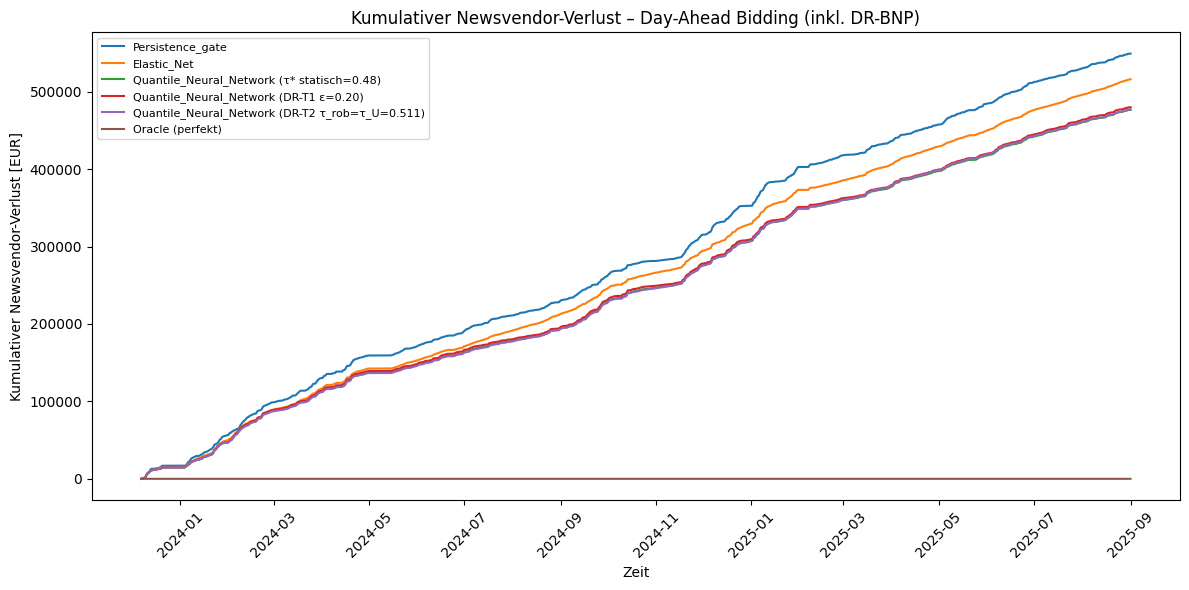

In [155]:
# Auswahl relevanter Modelle für die Grafik
plot_models = [
    "Persistence_gate",
    "Elastic_Net",
    f"Quantile_Neural_Network (τ* statisch={tau_star:.2f})",
    f"Quantile_Neural_Network (DR-T1 ε=0.20)",
    f"Quantile_Neural_Network (DR-T2 τ_rob=τ_U={tau_U:.3f})",
    "Oracle (perfekt)",
]

result_map = {r["model"]: r for r in results}

fig, ax = plt.subplots(figsize=(12, 6))

timestamps = df["timestamp"].values

for name in plot_models:
    if name not in result_map:
        print(f"  [WARN] Modell nicht gefunden: {name}")
        continue
    cum_loss = np.cumsum(result_map[name]["_nv_loss"])
    ax.plot(timestamps, cum_loss, label=name)

ax.set_xlabel("Zeit")
ax.set_ylabel("Kumulativer Newsvendor-Verlust [EUR]")
ax.set_title("Kumulativer Newsvendor-Verlust – Day-Ahead Bidding (inkl. DR-BNP)")
ax.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cumulative_nv_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Grafik: Kumulativer Gewinn über Zeit

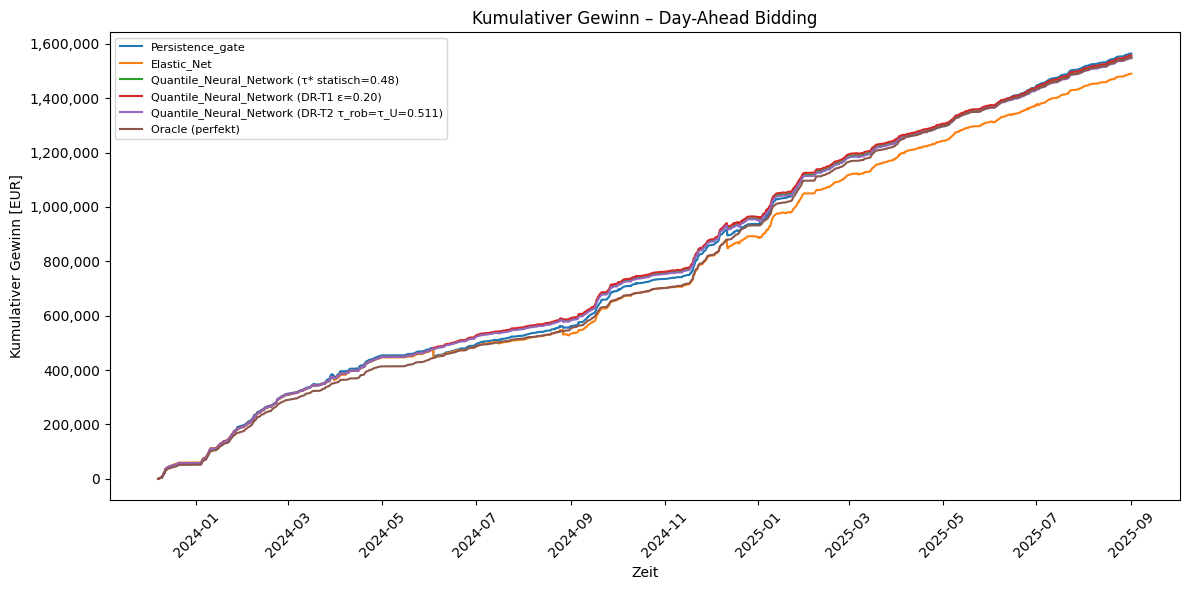

In [156]:
fig, ax = plt.subplots(figsize=(12, 6))

for name in plot_models:
    if name not in result_map:
        continue
    cum_profit = np.cumsum(result_map[name]["_profits"])
    ax.plot(timestamps, cum_profit, label=name)

ax.set_xlabel("Zeit")
ax.set_ylabel("Kumulativer Gewinn [EUR]")
ax.set_title("Kumulativer Gewinn – Day-Ahead Bidding")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cumulative_profit_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Grafik: Modellvergleich (mean Newsvendor Loss)

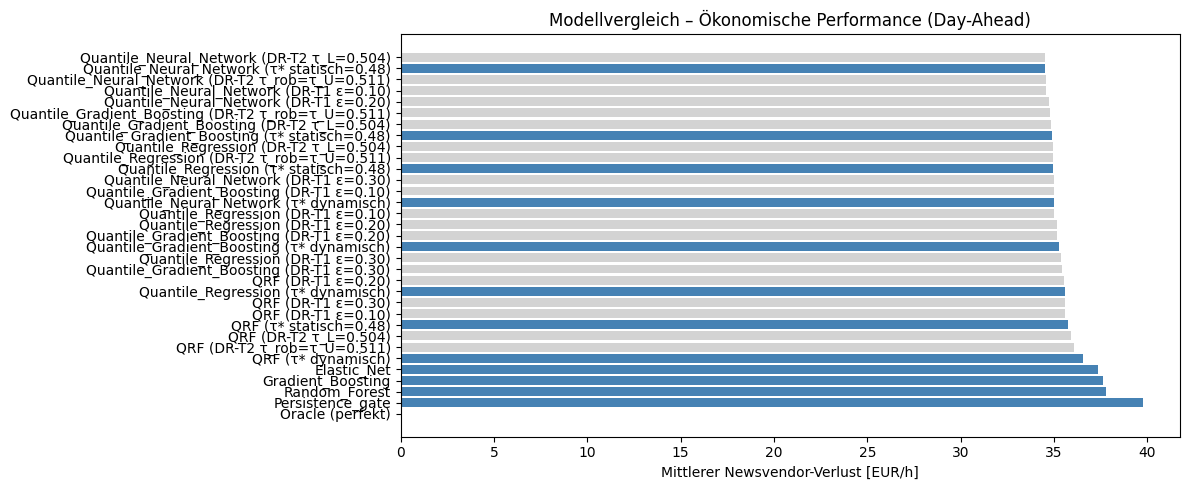

In [157]:
# Nur die Newsvendor-optimierten Bids der prob. Modelle + alle Point Forecasts
plot_df = summary[
    ~summary["model"].str.contains("q50") |
    summary["model"].isin(["Persistence_gate", "Elastic_Net", "Random_Forest", "Gradient_Boosting"])
].copy()

# Oracle ans Ende
oracle_row = plot_df[plot_df["model"] == "Oracle (perfekt)"]
plot_df = pd.concat([
    plot_df[plot_df["model"] != "Oracle (perfekt)"],
    oracle_row,
])

fig, ax = plt.subplots(figsize=(12, 5))
colors = [
    "steelblue" if "τ*" in m or m in ["Persistence_gate", "Elastic_Net", "Random_Forest", "Gradient_Boosting"]
    else "lightgray"
    for m in plot_df["model"]
]
colors[-1] = "gold"  # Oracle

ax.barh(plot_df["model"], plot_df["mean_nv_loss"], color=colors)
ax.set_xlabel("Mittlerer Newsvendor-Verlust [EUR/h]")
ax.set_title("Modellvergleich – Ökonomische Performance (Day-Ahead)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_nv_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. QNN-Prognoseband vs. tatsächliche Produktion

Visualisierung der probabilistischen QNN-Prognose über den gesamten Testzeitraum.  
Das Prognoseband (q10–q90) sollte ~80 % der tatsächlichen Werte abdecken.  
Jeder Abschnitt zeigt ca. 6 Monate für eine gute Lesbarkeit.

In [ ]:
import matplotlib.patches as mpatches

# Okabe-Ito colorblind-friendly palette
PROB_PLOT_MODELS = {
    "Quantile Regression": ("quantile_regression", "#CC79A7"),
    "QRF":                 ("qrf",                 "#0072B2"),
    "QGB":                 ("qgb",                 "#D55E00"),
    "QNN":                 ("qnn",                 "#009E73"),
}
POINT_PLOT_MODELS = {
    "Persistence (Gate)": (df["persistence_gate"].values,  "#999999"),
    "Elastic Net":        (df["elastic_net"].values,        "#E69F00"),
    "Random Forest":      (df["random_forest"].values,      "#56B4E9"),
    "Gradient Boosting":  (df["gradient_boosting"].values,  "#785EF0"),
}

df_ts = pd.to_datetime(df["timestamp"])

cuts = pd.date_range(
    df_ts.min().to_period("Q").to_timestamp(),
    df_ts.max() + pd.DateOffset(months=3),
    freq="6MS",
)
panels = [(cuts[i], cuts[i + 1]) for i in range(len(cuts) - 1) if cuts[i] < df_ts.max()]

def period_label(t_start, t_end):
    return f"{t_start.strftime('%b %Y')}–{min(t_end, df_ts.max()).strftime('%b %Y')}"

def draw_violations(ax, t_arr, actual, q_low, q_high):
    outside = (np.array(actual) < np.array(q_low)) | (np.array(actual) > np.array(q_high))
    changes = np.diff(outside.astype(int), prepend=0, append=0)
    starts  = np.where(changes ==  1)[0]
    ends    = np.where(changes == -1)[0]
    for s, e in zip(starts, ends):
        ax.axvspan(t_arr[s], t_arr[min(e, len(t_arr) - 1)],
                   color="red", alpha=0.15, zorder=0, linewidth=0)
    return len(starts)

# --- Probabilistische Modelle ---
for model_name, (prefix, color) in PROB_PLOT_MODELS.items():
    bid_arr = get_quantile_bid(prefix, tau_star)
    q10_arr = df[f"{prefix}_q10"].values
    q90_arr = df[f"{prefix}_q90"].values

    for t_start, t_end in panels:
        mask  = (df_ts >= t_start) & (df_ts < t_end)
        t_arr = df_ts[mask].values
        if len(t_arr) == 0:
            continue

        fig, ax = plt.subplots(figsize=(16, 4))

        n_viol = draw_violations(ax, t_arr, y_true[mask], q10_arr[mask], q90_arr[mask])

        ax.fill_between(t_arr, q10_arr[mask], q90_arr[mask],
                        alpha=0.18, color=color)
        ax.plot(t_arr, bid_arr[mask], linewidth=0.9, color=color, alpha=0.9)
        ax.plot(t_arr, y_true[mask],  linewidth=1.0, color="black", zorder=5)

        legend_handles = [
            mpatches.Patch(facecolor="black",  label="Tatsächliche Produktion"),
            mpatches.Patch(facecolor=color,    label=f"{model_name} τ*-Gebot (Q{tau_star:.2f})"),
            mpatches.Patch(facecolor=color, alpha=0.3, label="q10–q90 Prognoseband"),
            mpatches.Patch(facecolor="red", alpha=0.3, label=f"Außerhalb Band ({n_viol} Blöcke)"),
        ]
        ax.legend(handles=legend_handles, fontsize=9, loc="upper right")

        ax.set_ylabel("Energie [MWh]")
        ax.set_xlabel("Zeit")
        ax.set_title(f"{model_name} – Gebot & Prognoseband ({period_label(t_start, t_end)})")
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d.%m.%y"))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0, interval=2))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
        plt.tight_layout()

        fname = f"bid_vs_actual_{prefix}_{t_start.strftime('%Y%m')}.png"
        plt.savefig(FIGURES_DIR / fname, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Gespeichert: {fname}  |  {n_viol} Verletzungsblöcke")

# --- Point-Modelle ---
for model_name, (bid_arr, color) in POINT_PLOT_MODELS.items():
    for t_start, t_end in panels:
        mask  = (df_ts >= t_start) & (df_ts < t_end)
        t_arr = df_ts[mask].values
        if len(t_arr) == 0:
            continue

        fig, ax = plt.subplots(figsize=(16, 4))
        ax.plot(t_arr, bid_arr[mask], linewidth=0.9, color=color, alpha=0.9)
        ax.plot(t_arr, y_true[mask],  linewidth=1.0, color="black", zorder=5)

        legend_handles = [
            mpatches.Patch(facecolor="black", label="Tatsächliche Produktion"),
            mpatches.Patch(facecolor=color,   label=f"{model_name} Gebot"),
        ]
        ax.legend(handles=legend_handles, fontsize=9, loc="upper right")

        ax.set_ylabel("Energie [MWh]")
        ax.set_xlabel("Zeit")
        ax.set_title(f"{model_name} – Gebot vs. tatsächliche Produktion ({period_label(t_start, t_end)})")
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d.%m.%y"))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0, interval=2))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
        plt.tight_layout()

        slug  = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        fname = f"bid_vs_actual_{slug}_{t_start.strftime('%Y%m')}.png"
        plt.savefig(FIGURES_DIR / fname, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Gespeichert: {fname}")

In [ ]:
nv_comparison_rows = []

for col_prefix, display_name in prob_models.items():
    q50_name   = f"{display_name} (q50)"
    stat_name  = f"{display_name} (τ* statisch={tau_star:.2f})"
    dyn_name   = f"{display_name} (τ* dynamisch)"
    dr_t1_name = f"{display_name} (DR-T1 ε=0.20)"
    dr_t2_name = f"{display_name} (DR-T2 τ_rob=τ_U={tau_U:.3f})"

    row = {"model": display_name}
    for key, nm in [
        ("nv_loss_q50",     q50_name),
        ("nv_loss_tau_stat", stat_name),
        ("nv_loss_tau_dyn",  dyn_name),
        ("nv_loss_dr_t1",    dr_t1_name),
        ("nv_loss_dr_t2",    dr_t2_name),
    ]:
        if nm in result_map:
            row[key] = result_map[nm]["mean_nv_loss"]
    nv_comparison_rows.append(row)

nv_comparison = pd.DataFrame(nv_comparison_rows)
nv_comparison.to_csv(TABLES_DIR / "newsvendor_strategy_comparison.csv", index=False)
display(nv_comparison)

,model,nv_loss_q50,nv_loss_tau_stat,nv_loss_tau_dyn,nv_loss_dr_t1,nv_loss_dr_t2
0,Quantile_Regression,34.929074,34.948079,35.570171,35.165858,34.934289
1,QRF,35.917939,35.728620,36.523728,35.537112,36.076036
2,Quantile_Gradient_Boosting,34.818788,34.894063,35.271566,35.178775,34.784031
3,Quantile_Neural_Network,34.500921,34.504507,35.011895,34.748221,34.548377


## 15. Tägliche Prognosequalität (Day-Ahead Tagessummen)

Aggregiert stündliche Prognosen zu Tagesgesamtproduktion und berechnet
MAE / RMSE auf Tagesbasis — entspricht der Fragestellung "wie gut sagt das Modell
den nächsten Tag voraus?"

Gespeichert: daily_forecast_metrics_day_ahead.csv


,Modell,Tägl. MAE,Tägl. RMSE
0,Gradient Boosting,23.58,31.21
1,Elastic Net,23.47,31.73
2,Random Forest,24.03,31.77
3,QRF q50,23.30,33.14
4,QNN q50,22.45,33.48
5,QGB q50,22.82,33.90
6,Persistence (Gate),28.56,41.57


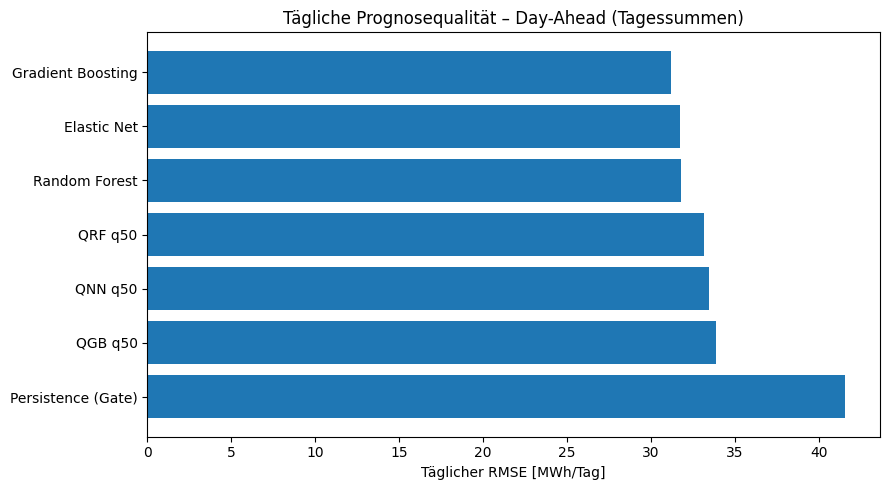

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error as mse_fn

# Tagesaggregation: stündliche Prognosen → Tagesgesamtproduktion (MWh/Tag)
df["date"] = df["timestamp"].dt.date
df_daily = df.groupby("date").agg(
    y_true           =("y_true",          "sum"),
    persistence_gate =("persistence_gate", "sum"),
    elastic_net      =("elastic_net",      "sum"),
    random_forest    =("random_forest",    "sum"),
    gradient_boosting=("gradient_boosting","sum"),
    qgb_q50          =("qgb_q50",          "sum"),
    qrf_q50          =("qrf_q50",          "sum"),
    qnn_q50          =("qnn_q50",          "sum"),
).reset_index()

daily_metrics = []
model_cols = {
    "Persistence (Gate)": "persistence_gate",
    "Elastic Net":        "elastic_net",
    "Random Forest":      "random_forest",
    "Gradient Boosting":  "gradient_boosting",
    "QGB q50":            "qgb_q50",
    "QRF q50":            "qrf_q50",
    "QNN q50":            "qnn_q50",
}
for label, col in model_cols.items():
    daily_metrics.append({
        "Modell":       label,
        "Tägl. MAE":    round(mean_absolute_error(df_daily["y_true"], df_daily[col]), 2),
        "Tägl. RMSE":   round(np.sqrt(mse_fn(df_daily["y_true"], df_daily[col])), 2),
    })

daily_summary = pd.DataFrame(daily_metrics).sort_values("Tägl. RMSE").reset_index(drop=True)
daily_summary.to_csv(TABLES_DIR / "daily_forecast_metrics_day_ahead.csv", index=False)
print("Gespeichert: daily_forecast_metrics_day_ahead.csv")
display(daily_summary)

# Balkendiagramm
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(daily_summary["Modell"], daily_summary["Tägl. RMSE"])
ax.set_xlabel("Täglicher RMSE [MWh/Tag]")
ax.set_title("Tägliche Prognosequalität – Day-Ahead (Tagessummen)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "daily_rmse_day_ahead.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Zusammenfassung

Zentrale Befunde:

In [ ]:
print("tau_star:", tau_star)
print("c_under:", c_under)
print("c_over:", c_over)
print("p_rebap sample:", p_rebap[:5])
print("p_da sample:   ", p_da[:5])

tau_star: 0.4826225794357422
c_under: 28.565842092414837
c_over: 30.6229387678022
p_rebap sample: [139.34   146.8    147.8975 193.785  216.9925]
p_da sample:    [ 91.81  89.92  94.53 116.58 131.22]
